In [43]:
import sys
sys.path.append("../src")
from load_history import load_streaming_history
import pandas as pd

df = load_streaming_history("../data")
df.head()

,ts,platform,ms_played,conn_country,ip_addr,track,artist,album,track_uri,episode_name,...,shuffle,skipped,offline,offline_timestamp,incognito_mode,minutes_played,hour,day_of_week,date,month
0,2018-08-06 11:50:53+00:00,"iOS 11.4 (iPhone6,2)",217925,JP,161.202.165.114,In My Feelings,Drake,Scorpion,spotify:track:2G7V7zsVDxg1yRsu7Ew9RJ,NaN,...,False,False,False,NaN,False,3.632083,11,Monday,2018-08-06,2018-08
1,2018-08-06 11:50:58+00:00,"iOS 11.4 (iPhone6,2)",724,JP,161.202.165.114,Only You (with Little Mix),Cheat Codes,Only You (with Little Mix),spotify:track:54l9GJGQ1UCFKe2tzt1Vxt,NaN,...,False,False,False,NaN,False,0.012067,11,Monday,2018-08-06,2018-08
2,2018-08-06 11:54:24+00:00,"iOS 11.4 (iPhone6,2)",205101,JP,161.202.165.114,Back To You - From 13 Reasons Why – Season 2 S...,Selena Gomez,Back To You,spotify:track:4hQ6UGyWQIGJmHSo0J88JW,NaN,...,False,False,False,NaN,False,3.418350,11,Monday,2018-08-06,2018-08
3,2018-08-06 11:54:28+00:00,"iOS 11.4 (iPhone6,2)",3366,JP,161.202.165.114,SICKO MODE,Travis Scott,ASTROWORLD,spotify:track:2xLMifQCjDGFmkHkpNLD9h,NaN,...,False,False,False,NaN,False,0.056100,11,Monday,2018-08-06,2018-08
4,2018-08-06 11:56:48+00:00,"iOS 11.4 (iPhone6,2)",75882,JP,161.202.165.114,2002,Anne-Marie,2002,spotify:track:4Pbg79cTBu4vgSphoyNq3j,NaN,...,False,False,False,NaN,False,1.264700,11,Monday,2018-08-06,2018-08


lets categorise listening sessions, identified by finding gaps between plays that are longer than 20mins. 

In [44]:
def add_session_ids(df: pd.DataFrame, gap_minutes: int = 20) -> pd.DataFrame:
    df = df.sort_values("ts")
    df["gap_minutes"] = df["ts"].diff() #this shifts each timestamp by 1 place down and finds the diff with above timestamp
    df["gap_minutes"] = df["gap_minutes"].dt.total_seconds() / 60 #conversion from timedelta to datetime to numeric
    df["is_new_session"] = df["gap_minutes"] > 20 #boolean flag for is new session if gap is larger than 20min
    df["session_id"] = df["is_new_session"].cumsum() #cumsum makes false false true false true turn into 0 0 1 1 2

    return df


df = add_session_ids(df)
df["session_id"].nunique() #12479 unique sessions

12479

12479 sessions and 178341 plays across 8 years is 4.3 sessions per day and 14.3 tracks per sessions

In [45]:
df.groupby("session_id").size().describe()

count    12479.000000
mean        14.291289
std         20.225191
min          1.000000
25%          2.000000
50%          8.000000
75%         18.000000
max        307.000000
dtype: float64

lets investigate this max session of 307 songs

In [46]:
biggest = df.groupby("session_id").size().idxmax()
df[df["session_id"] == biggest][["ts", "track", "artist"]]

,ts,track,artist
75540,2021-11-18 00:22:00+00:00,"Piano Concerto in A Minor, Op. 16: II. Adagio",Edvard Grieg
75539,2021-11-18 00:22:00+00:00,Just For Today,Clairo
75538,2021-11-18 00:22:00+00:00,Coffee,beabadoobee
75537,2021-11-18 00:22:00+00:00,"Elgar: Cello Concerto in E Minor, Op. 85: III....",Edward Elgar
75536,2021-11-18 00:22:00+00:00,"Piano Concerto No. 1 in E minor, Op. 11: 2. Ro...",Frédéric Chopin
...,...,...,...
75433,2021-11-18 00:22:00+00:00,Love Like That,Lauv
75432,2021-11-18 00:22:00+00:00,Bloom - Bonus Track,The Paper Kites
75431,2021-11-18 00:22:00+00:00,"Drei Intermezzi, Op. 117: II. Andante non trop...",Johannes Brahms
75430,2021-11-18 00:22:00+00:00,Was It Something I Said,MyKey


seems like a lot of songs have the same timestamp, might be a bug, lets see how widespread this is.

In [47]:
dupe_counts = df["ts"].value_counts()
dupe_counts[dupe_counts > 1].describe()

count    2807.000000
mean        6.783399
std        12.058339
min         2.000000
25%         2.000000
50%         2.000000
75%         7.000000
max       307.000000
Name: count, dtype: float64

2 plays skipped in the same timestamp is quite normal, could be that i click fast... majority of them are 2 plays

In [48]:
big = dupe_counts[dupe_counts > 10]
print(len(big), "groups over size 10")
print(big.sum(), "rows involved")

510 groups over size 10
12225 rows involved


it is better to clean up these rows (around 6.9% of the data), but it means we need to restart from scratch and clean it first before grouping into sessions

In [49]:
bad_ts = dupe_counts[dupe_counts > 10].index #this creates the list of bad_timestamps and have dupe counts more than 10
df = df[~df["ts"].isin(bad_ts)] # keep the timestamps that are not in the bad_ts dataframe
df = add_session_ids(df)
df.groupby("session_id").size().describe()

count    12278.000000
mean        13.529565
std         19.581836
min          1.000000
25%          2.000000
50%          7.000000
75%         17.000000
max        279.000000
dtype: float64

investigating again...

In [50]:
biggest = df.groupby("session_id").size().idxmax()
df[df["session_id"] == biggest][["ts", "track", "artist"]]

,ts,track,artist
81220,2022-01-26 13:26:25+00:00,It Never Entered My Mind,Mulgrew Miller
81221,2022-01-26 13:26:26+00:00,Young One for Debra,Jim Hall
81222,2022-01-26 13:26:39+00:00,So This Is Love - previously unreleased altern...,Dave Brubeck
81223,2022-01-26 13:31:57+00:00,The Ghosts of Beverly Drive,Death Cab for Cutie
81224,2022-01-26 13:32:08+00:00,Transatlanticism,Death Cab for Cutie
...,...,...,...
81494,2022-01-26 15:53:10+00:00,Raised By Wolves,Voxtrot
81495,2022-01-26 15:53:24+00:00,The Start Of Something,Voxtrot
81496,2022-01-26 15:53:29+00:00,"Mothers, Sisters, Daughters & Wives",Voxtrot
81497,2022-01-26 15:57:37+00:00,A Couple Things,Kate Bollinger


thats more like it... the timestamps for this 279 song session are reasonably spaced apart. lets make some more columns

In [51]:
df["position_in_session"] = df.groupby("session_id").cumcount()
df["artist_plays_so_far"] = df.groupby("artist").cumcount()
df["track_plays_so_far"] = df.groupby("track_uri").cumcount()
df["days_since_track_last_played"] = df.groupby("track_uri")["ts"].diff().dt.total_seconds() / 86400

In [52]:
df[df["track"] == "Comfortably Numb"]

,ts,platform,ms_played,conn_country,ip_addr,track,artist,album,track_uri,episode_name,...,day_of_week,date,month,gap_minutes,is_new_session,session_id,position_in_session,artist_plays_so_far,track_plays_so_far,days_since_track_last_played
48387,2020-12-29 08:57:14+00:00,OS X 10.14.6 [x86 8],102346,SG,116.15.152.113,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Tuesday,2020-12-29,2020-12,489.916667,True,2826,0,10,0,NaN
48388,2020-12-29 15:19:18+00:00,OS X 10.14.6 [x86 8],247551,SG,116.15.152.113,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Tuesday,2020-12-29,2020-12,382.066667,True,2827,0,11,1,0.265324
49620,2021-01-15 05:12:36+00:00,OS X 10.14.6 [x86 8],113173,SG,202.55.72.74,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Friday,2021-01-15,2021-01,1.866667,False,2909,1,21,2,16.578681
50785,2021-02-04 10:31:08+00:00,OS X 10.14.6 [x86 8],382296,SG,116.15.152.113,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Thursday,2021-02-04,2021-02,6.366667,False,3000,27,34,3,20.221204
50814,2021-02-04 23:01:22+00:00,"iOS 13.7 (iPhone9,3)",382296,SG,183.90.36.171,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Thursday,2021-02-04,2021-02,6.700000,False,3002,8,36,4,0.520995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144127,2024-11-24 08:08:26+00:00,ios,157686,SG,122.11.212.21,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Sunday,2024-11-24,2024-11,17.866667,False,9376,13,857,78,0.999537
151056,2025-04-27 15:31:24+00:00,ios,211719,SG,203.127.57.30,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Sunday,2025-04-27,2025-04,354.700000,True,9965,0,890,79,154.307616
151057,2025-04-28 09:04:33+00:00,ios,384221,SG,122.11.214.225,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Monday,2025-04-28,2025-04,1053.150000,True,9966,0,891,80,0.731354
157406,2025-09-16 06:36:16+00:00,ios,15886,SG,137.132.26.211,Comfortably Numb,Pink Floyd,The Wall,spotify:track:5HNCy40Ni5BZJFw1TKzRsC,NaN,...,Tuesday,2025-09-16,2025-09,0.283333,False,10462,46,926,81,140.897025


looks legit, we can move on now.

the idea is to build a predictive model on identifying when I will skip a track. lets split the data into 80% training, on earlier data, to test it on the remaining 20% of data. We will split based on timestamp, chronologically.

In [53]:
cutoff = df["ts"].quantile(0.8)
train = df[df["ts"] < cutoff]
test = df[df["ts"] >= cutoff]

print(len(train), len(test))
print(train["ts"].max(), test["ts"].min())
print(test["skipped"].mean(), train["skipped"].mean())


132892 33224
2024-12-14 10:36:00+00:00 2024-12-14 10:36:03+00:00
0.46123284372742596 0.16525449236974385


that is weird, why are the two means so different, lets break it down by year

In [54]:
df.groupby(df["ts"].dt.year)["skipped"].mean()

ts
2018    0.000000
2019    0.000000
2020    0.000000
2021    0.000000
2022    0.082579
2023    0.515105
2024    0.638287
2025    0.496571
2026    0.414117
Name: skipped, dtype: float64

it seems like the skipped feature is only tracked in 2022 

In [55]:
df[df["ts"].dt.year == 2022].groupby(df["ts"].dt.month)["skipped"].mean()

ts
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.229189
11    0.463177
12    0.569200
Name: skipped, dtype: float64

skipped only starts being tracked from october 2022 onwards. so lets filter it to those

In [56]:
df = df[df["ts"] >= "2022-10-01"]
df.count()

ts                              73359
platform                        73359
ms_played                       73359
conn_country                    73359
ip_addr                         73359
track                           73359
artist                          73359
album                           73359
track_uri                       73359
episode_name                        0
episode_show_name                   0
spotify_episode_uri                 0
audiobook_title                     0
audiobook_uri                       0
audiobook_chapter_uri               0
audiobook_chapter_title             0
reason_start                    73359
reason_end                      73359
shuffle                         73359
skipped                         73359
offline                         73358
offline_timestamp               71755
incognito_mode                  73359
minutes_played                  73359
hour                            73359
day_of_week                     73359
date        

we first encode categorical data as random forest needs numbers.
we also clean up the NaNs in days_since_track_last_played, which would be NaN for a new song.

In [57]:
df["platform_encoded"] = df["platform"].astype("category").cat.codes
df["day_of_week_encoded"] = df["day_of_week"].astype("category").cat.codes
df["reason_start_encoded"] = df["reason_start"].astype("category").cat.codes
df["days_since_track_last_played"] = df["days_since_track_last_played"].fillna(-1)


In [58]:
cutoff = df["ts"].quantile(0.8)
train = df[df["ts"] < cutoff]
test = df[df["ts"] >= cutoff]

print(len(train), len(test))
print(train["ts"].max(), test["ts"].min())
print(test["skipped"].mean(), train["skipped"].mean())

58687 14672
2025-12-09 16:42:20+00:00 2025-12-09 16:42:23+00:00
0.4197791712104689 0.5303729957230733


lets make the RF model

In [63]:
df.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr', 'track',
       'artist', 'album', 'track_uri', 'episode_name', 'episode_show_name',
       'spotify_episode_uri', 'audiobook_title', 'audiobook_uri',
       'audiobook_chapter_uri', 'audiobook_chapter_title', 'reason_start',
       'reason_end', 'shuffle', 'skipped', 'offline', 'offline_timestamp',
       'incognito_mode', 'minutes_played', 'hour', 'day_of_week', 'date',
       'month', 'gap_minutes', 'is_new_session', 'session_id',
       'position_in_session', 'artist_plays_so_far', 'track_plays_so_far',
       'days_since_track_last_played', 'platform_encoded',
       'day_of_week_encoded', 'reason_start_encoded'],
      dtype='str')

In [64]:
feature_cols = ["platform_encoded", "hour", "day_of_week_encoded", "shuffle", "reason_start_encoded",
"position_in_session", "artist_plays_so_far", "track_plays_so_far", "days_since_track_last_played"]  
X_train = train[feature_cols]
y_train = train["skipped"]
X_test = test[feature_cols]
y_test = test["skipped"]

lets see the baseline

In [65]:
y_test.value_counts(normalize=True)

skipped
False    0.580221
True     0.419779
Name: proportion, dtype: float64

the RF needs to beat 58% for it to learn something about skip behaviour

In [66]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

model generated, lets test it on the tes set

In [67]:
y_pred = clf.predict(X_test)

generate report

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.78      0.78      0.78      8513
        True       0.69      0.70      0.69      6159

    accuracy                           0.74     14672
   macro avg       0.74      0.74      0.74     14672
weighted avg       0.74      0.74      0.74     14672



In [69]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[6620, 1893],
       [1877, 4282]])

now lets compute the ROC-AUC score

In [70]:
from sklearn.metrics import roc_auc_score

y_proba = clf.predict_proba(X_test)[:, 1]  # probability of class True (skipped)
roc_auc_score(y_test, y_proba)

0.8075775229071449

ok lets see which feature is leaned on more

In [71]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

reason_start_encoded            0.237127
artist_plays_so_far             0.165416
days_since_track_last_played    0.154316
position_in_session             0.126284
track_plays_so_far              0.103068
hour                            0.095742
day_of_week_encoded             0.062961
platform_encoded                0.038567
shuffle                         0.016518
dtype: float64

the results show that reason_start_encoded is the top signal for indicating if a track were to be skipped. After all, tracks that I deliberately chose would not be skipped because I deliberately chose them, but a track played from shuffle might be likely to be skipped.

artist_plays_so_far is another top signal, which also makes sense, since if i keep playing an artist for a long time, i might be more likely to skip a song.

days_since_track_last_played is also another top indicator as it means that if i have been playing a track for quite some time i am more likely to skip it.

this model is not too bad, the model beats baseline by 16 points and has a solid 0.81 AUC separation.

lets look into reason_start

In [72]:
df["reason_start"].value_counts()

reason_start
trackdone            32825
clickrow             21333
fwdbtn               13612
playbtn               2935
appload               1212
backbtn                484
remote                 450
unknown                447
trackerror              50
reconnect               10
switched-to-audio        1
Name: count, dtype: int64

In [73]:
df["reason_start"].astype("category").cat.categories


Index(['appload', 'backbtn', 'clickrow', 'fwdbtn', 'playbtn', 'reconnect',
       'remote', 'switched-to-audio', 'trackdone', 'trackerror', 'unknown'],
      dtype='str')

In [74]:
df.groupby("reason_start")["skipped"].mean().sort_values(ascending=False)


reason_start
unknown              0.892617
clickrow             0.755449
fwdbtn               0.751029
playbtn              0.635094
trackerror           0.480000
appload              0.470297
remote               0.431111
backbtn              0.429752
reconnect            0.400000
trackdone            0.234059
switched-to-audio    0.000000
Name: skipped, dtype: float64

lets do some k-means clustering on these sessions
we begin by aggregating the features per session.

In [77]:
session_features = df.groupby("session_id").agg(
    track_count=("track", "count"),
    total_minutes=("minutes_played", "sum"),
    unique_artists=("artist", "nunique"),
    skip_rate=("skipped", "mean"),
    shuffle_rate=("shuffle", "mean"),
    start_hour=("hour", "first"),
)

session_features.head()


,track_count,total_minutes,unique_artists,skip_rate,shuffle_rate,start_hour
session_id,,,,,,
6504,12,40.141017,11,0.0,0.250000,2
6505,6,41.161633,4,0.0,0.500000,3
6506,1,1.373483,1,0.0,0.000000,5
6507,18,53.122500,11,0.0,0.888889,8
6508,8,19.992017,6,0.0,1.000000,9


In [78]:
session_features.describe()

,track_count,total_minutes,unique_artists,skip_rate,shuffle_rate,start_hour
count,5774.000000,5774.000000,5774.000000,5774.000000,5774.000000,5774.000000
mean,12.705057,29.717470,7.795116,0.394748,0.597308,9.719952
std,17.196457,32.679874,9.502328,0.346374,0.438207,5.433155
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,3.000000,7.065858,2.000000,0.000000,0.000000,5.000000
50%,7.000000,20.436783,5.000000,0.352941,0.833333,10.000000
75%,16.000000,40.751196,10.000000,0.666667,1.000000,14.000000
max,235.000000,330.788900,106.000000,1.000000,1.000000,23.000000


lets scale all the values down to between 0 and 1

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(session_features)

implementing the kmeans clustering

In [80]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_features, labels))

now lets plot k_range against inertias and k_range against silhouettes

Text(0, 0.5, 'inertia')

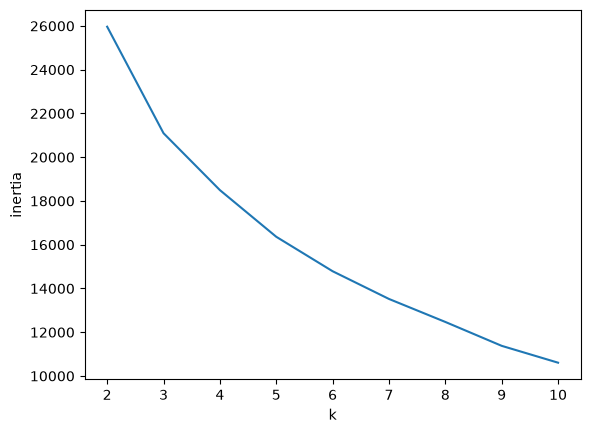

In [82]:
import matplotlib.pyplot as plt

plt.plot(k_range, inertias)
plt.xlabel("k")
plt.ylabel("inertia")



Text(0, 0.5, 'silhouettes')

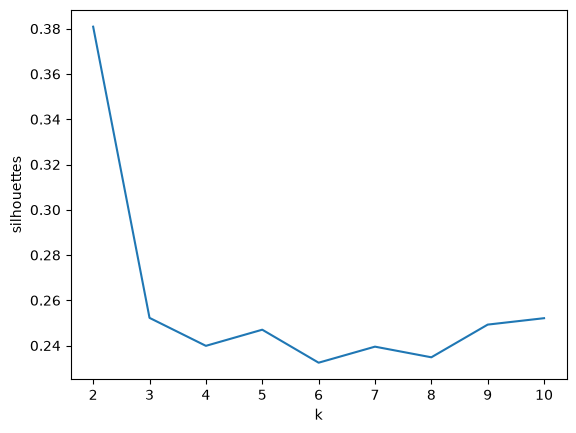

In [83]:
plt.plot(k_range, silhouettes)
plt.xlabel("k")
plt.ylabel("silhouettes")

the elbow from the inertia plot occurs at k=5 but the bend is very gradual, but from the silhouette plot, having only k=2 clusters may not be an interesting set of listening archetypes. we can try both and see, but first lets reach middle ground with k=4

In [85]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
session_features["cluster"] = kmeans.fit_predict(scaled_features)
session_features["cluster"].value_counts()

cluster
1    2034
0    1561
3    1543
2     636
Name: count, dtype: int64

In [86]:
session_features.groupby("cluster").mean()


,track_count,total_minutes,unique_artists,skip_rate,shuffle_rate,start_hour
cluster,,,,,,
0,7.481102,29.318488,3.419603,0.226445,0.051848,9.726457
1,7.423304,24.492083,5.771878,0.161668,0.958108,9.401672
2,48.509434,84.972623,27.863208,0.535438,0.710068,10.183962
3,10.194426,14.233977,6.616980,0.814272,0.627043,9.941672


to visually see that the clusters are actually separated, lets use PCA to de-dimensionalise the data.

Text(0, 0.5, 'PC2')

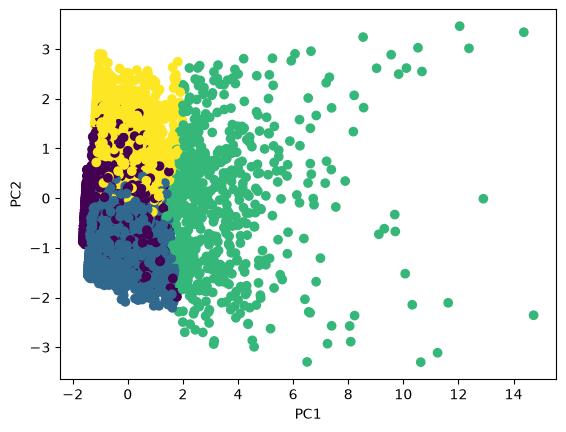

In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.scatter(pca_features[:, 0], pca_features[:, 1], c=session_features["cluster"], cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")

In [88]:
pca.explained_variance_ratio_

array([0.40852609, 0.18645101])

this means that only around 60% of the variance is captured by these two axes, so the clustering does not show evident separation, so it is difficult to visualise the 6 dimensional clustering.

we can take a look back at the original k means clusters, what exactly do they represent?

